<a href="https://colab.research.google.com/github/Krishnavenia68/Data-Analytics-Portfolio/blob/main/Amazon_Sales_Data_Analysis_using_Python_%26_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("Amazon Sale Report.csv")

/tmp/ipykernel_978/652367067.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


In [5]:
df = pd.read_csv("Amazon Sale Report.csv", low_memory=False)


In [6]:

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [8]:
print("Rows and Columns :", df.shape)

Rows and Columns : (128975, 24)


In [9]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


Data set cleanning

In [11]:

df_clean = df.copy()

In [12]:
print(df_clean.shape)

(128975, 24)


In [13]:
df_clean.dtypes

,0
index,int64
Order ID,object
Date,object
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Style,object
SKU,object
Category,object


In [14]:
missing_values = df_clean.isnull().sum()
missing_values[missing_values > 0]

,0
Courier Status,6872
currency,7795
Amount,7795
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33
promotion-ids,49153
fulfilled-by,89698
Unnamed: 22,49050


In [15]:
missing_percentage = (df_clean.isnull().sum()/len(df_clean))*100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
fulfilled-by,69.546811
promotion-ids,38.110487
Unnamed: 22,38.030626
currency,6.043807
Amount,6.043807
Courier Status,5.328164
ship-postal-code,0.025586
ship-state,0.025586
ship-city,0.025586
ship-country,0.025586


In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
df_clean.drop_duplicates(inplace=True)

In [18]:
df_clean.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [19]:
df_clean.columns = df_clean.columns.str.strip()

In [20]:
df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

In [21]:
df_clean['status'].unique()

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [22]:
df_clean['status'].value_counts()

,count
status,
Shipped,77804
Shipped - Delivered to Buyer,28769
Cancelled,18332
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


In [23]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

/tmp/ipykernel_978/4103588557.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date'] = pd.to_datetime(df_clean['date'])


In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128975 non-null  int64         
 1   order_id            128975 non-null  object        
 2   date                128975 non-null  datetime64[ns]
 3   status              128975 non-null  object        
 4   fulfilment          128975 non-null  object        
 5   sales_channel       128975 non-null  object        
 6   ship-service-level  128975 non-null  object        
 7   style               128975 non-null  object        
 8   sku                 128975 non-null  object        
 9   category            128975 non-null  object        
 10  size                128975 non-null  object        
 11  asin                128975 non-null  object        
 12  courier_status      122103 non-null  object        
 13  qty                 128975 no

In [25]:
df_clean.describe()

,index,date,qty,amount,ship-postal-code
count,128975.000000,128975,128975.000000,121180.000000,128942.000000
mean,64487.000000,2022-05-12 11:49:27.951928576,0.904431,648.561465,463966.236509
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,110001.000000
25%,32243.500000,2022-04-20 00:00:00,1.000000,449.000000,382421.000000
50%,64487.000000,2022-05-10 00:00:00,1.000000,605.000000,500033.000000
75%,96730.500000,2022-06-04 00:00:00,1.000000,788.000000,600024.000000
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000
std,37232.019822,NaN,0.313354,281.211687,191476.764941


In [26]:
df_clean.to_csv("amazon_sales_cleaned.csv", index=False)

In [27]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
fulfilled-by,89698
promotion-ids,49153
unnamed:_22,49050
currency,7795
amount,7795
courier_status,6872
ship-country,33
ship-city,33
ship-state,33
ship-postal-code,33


In [28]:
missing_percent = (df_clean.isnull().sum()/len(df_clean))*100

missing_percent.sort_values(ascending=False)

,0
fulfilled-by,69.546811
promotion-ids,38.110487
unnamed:_22,38.030626
currency,6.043807
amount,6.043807
courier_status,5.328164
ship-country,0.025586
ship-city,0.025586
ship-state,0.025586
ship-postal-code,0.025586


In [29]:
df_clean['unnamed:_22'].value_counts(dropna=False)

,count
unnamed:_22,
False,79925
NaN,49050


In [30]:
df_clean['fulfilled-by'].value_counts(dropna=False)

,count
fulfilled-by,
NaN,89698
Easy Ship,39277


In [31]:
df_clean['promotion-ids'].value_counts(dropna=False).head(10)

,count
promotion-ids,
NaN,49153
IN Core Free Shipping 2015/04/08 23-48-5-108,46100
Duplicated A12RHGVGRWOT3S 1560498941486,489
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-XX7G3ZRJJJ5LG,Amazon PLCC Free-Financing Universal Merchant AAT-LEHCKNDBJG64E,Amazon PLCC Free-Financing Universal Merchant AAT-DJVHCEV7D7RQY,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",458
Duplicated AYTJSBA8ZOP16 1567159860988,433
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-ETXQ3XXWMRXBG,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",316
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",305
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Fr

In [32]:
df_clean.drop(columns=['promotion-ids'], inplace=True)

In [33]:
df_clean['fulfilled-by'].value_counts(dropna=False)

,count
fulfilled-by,
NaN,89698
Easy Ship,39277


In [34]:
df_clean['unnamed:_22'].value_counts(dropna=False)

,count
unnamed:_22,
False,79925
NaN,49050


In [35]:
df_clean['fulfilled-by'].value_counts(dropna=False)

,count
fulfilled-by,
NaN,89698
Easy Ship,39277


In [36]:
df_clean['currency'].value_counts(dropna=False)

,count
currency,
INR,121180
NaN,7795


In [37]:
df_clean['currency'] = df_clean['currency'].fillna('INR')

In [38]:
df_clean['courier_status'].value_counts(dropna=False)

,count
courier_status,
Shipped,109487
NaN,6872
Unshipped,6681
Cancelled,5935


In [47]:
df_clean[df_clean['amount'].isnull()].head()

,index,order_id,date,status,fulfilment,sales_channel,ship-service-level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b,fulfilled-by,unnamed:_22
8,8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,INR,NaN,HYDERABAD,TELANGANA,500008.0,IN,False,NaN,NaN
29,29,404-5933402-8801952,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,JNE2132,JNE2132-KR-398-XXXL,kurta,3XL,B07JG3CND8,NaN,0,INR,NaN,GUWAHATI,ASSAM,781003.0,IN,False,Easy Ship,NaN
65,65,171-4137548-0481151,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3373,JNE3373-KR-XXL,kurta,XXL,B082W8RWN1,Cancelled,0,INR,NaN,Dahod,Gujarat,389151.0,IN,False,NaN,NaN
84,84,403-9950518-0349133,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,kurta,M,B08WPR5MCB,Cancelled,0,INR,NaN,HYDERABAD,TELANGANA,500072.0,IN,False,NaN,NaN
95,95,405-9112089-3379536,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-L,kurta,L,B081WSCKPQ,Cancelled,0,INR,NaN,PUNE,MAHARASHTRA,411046.0,IN,False,NaN,NaN


EDA ROADMAP


In [48]:
print(df_clean.duplicated().sum())

df_clean.isnull().sum().sort_values(ascending=False)

missing_percent.sort_values(ascending=False)

df_clean.describe()

df_clean.describe(include='object')

0


,order_id,status,fulfilment,sales_channel,ship-service-level,style,sku,category,size,asin,courier_status,currency,ship-city,ship-state,ship-country,fulfilled-by,unnamed:_22
count,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,122103,128975,128942,128942,128942,39277,79925
unique,120378,13,2,2,2,1377,7195,9,11,7190,3,1,8955,69,1,1,1
top,403-4984515-8861958,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,INR,BENGALURU,MAHARASHTRA,IN,Easy Ship,False
freq,12,77804,89698,128851,88615,4224,773,50284,22711,773,109487,128975,11217,22260,128942,39277,79925


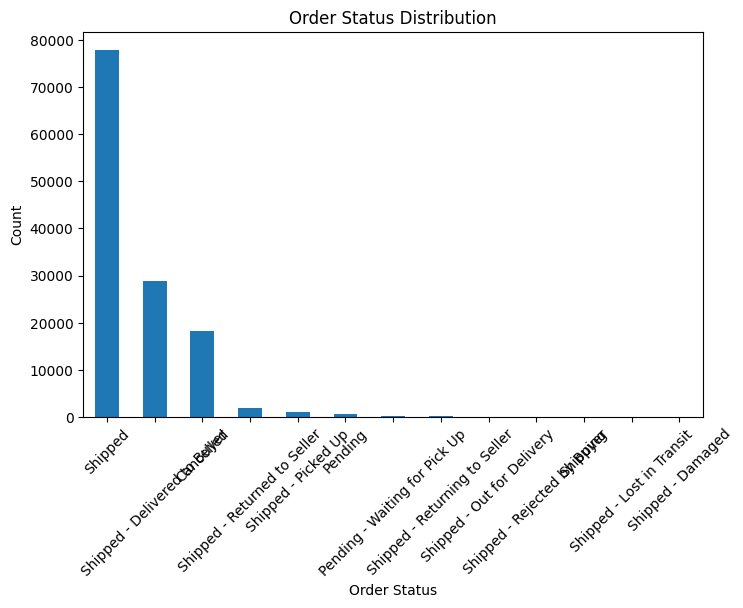

In [40]:
status_counts = df_clean['status'].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

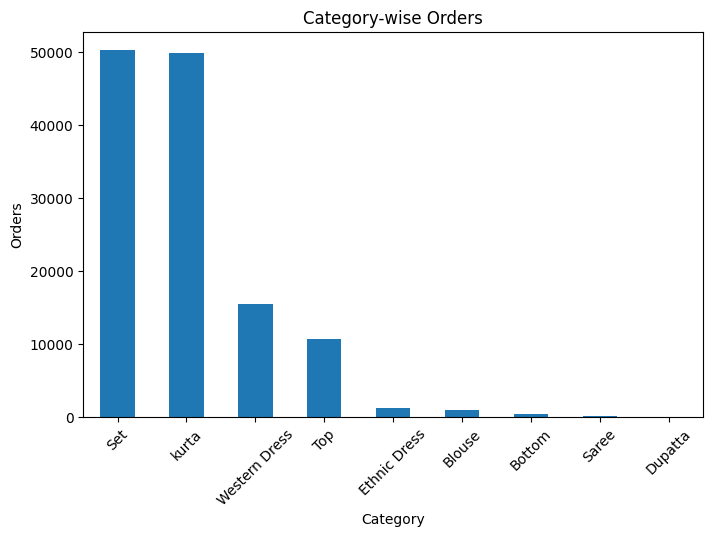

In [41]:
plt.figure(figsize=(8,5))
df_clean['category'].value_counts().plot(kind='bar')
plt.title('Category-wise Orders')
plt.xlabel('Category')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.show()

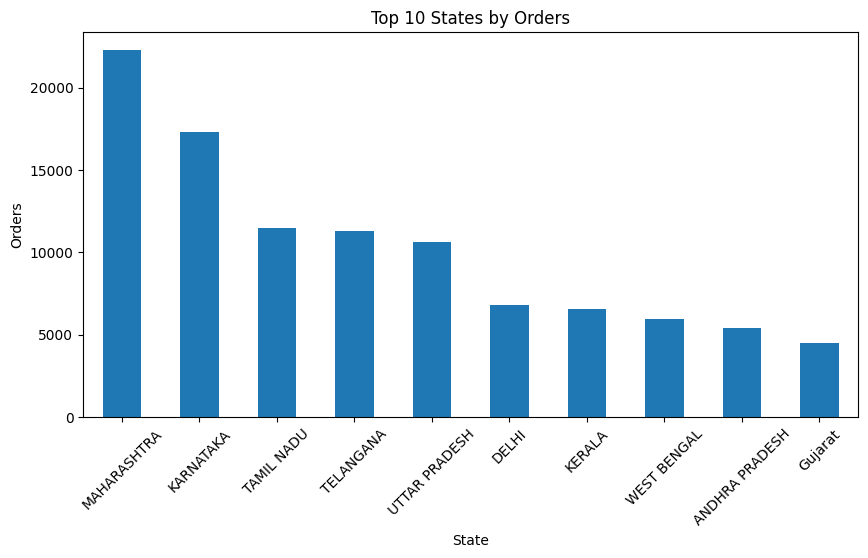

In [42]:
top_states = df_clean['ship-state'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Orders')
plt.xlabel('State')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.show()

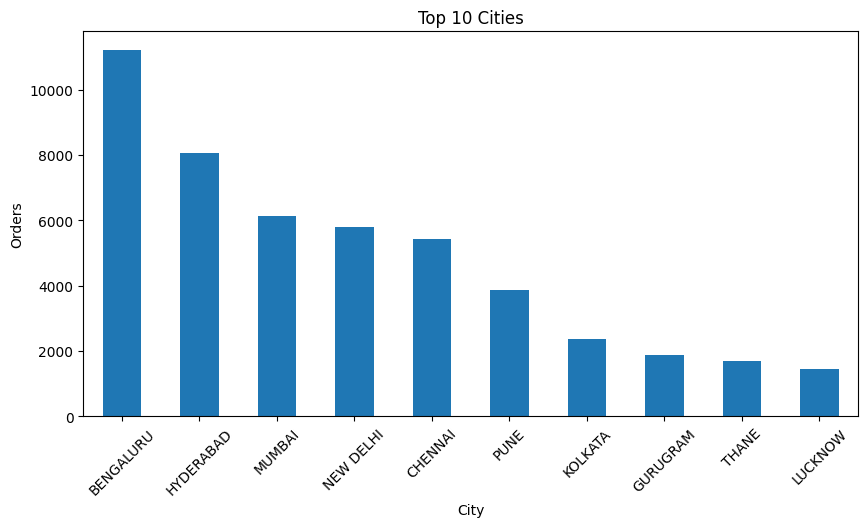

In [43]:
top_cities = df_clean['ship-city'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title('Top 10 Cities')
plt.xlabel('City')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.show()

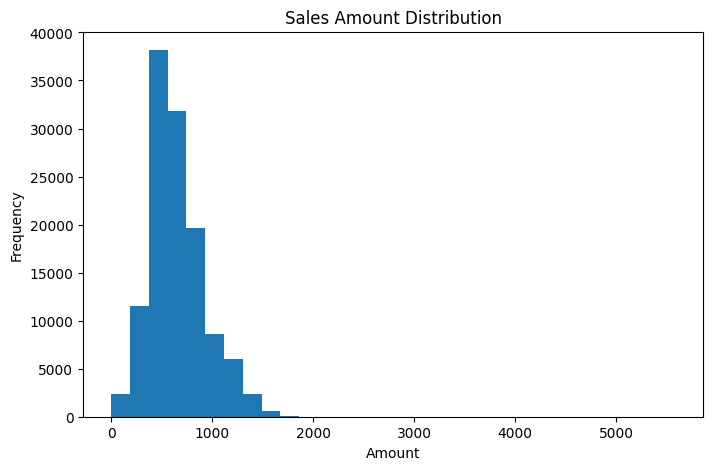

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['amount'].dropna(), bins=30)
plt.title('Sales Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

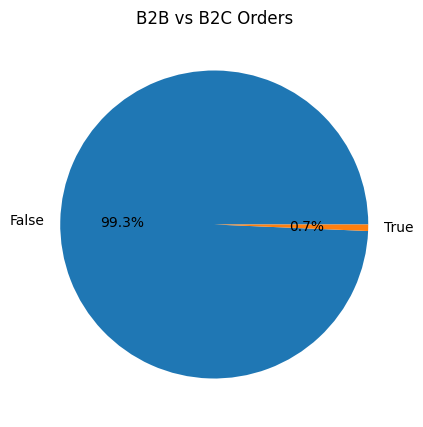

In [45]:
b2b_counts = df_clean['b2b'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(b2b_counts, labels=b2b_counts.index, autopct='%1.1f%%')
plt.title('B2B vs B2C Orders')
plt.show()

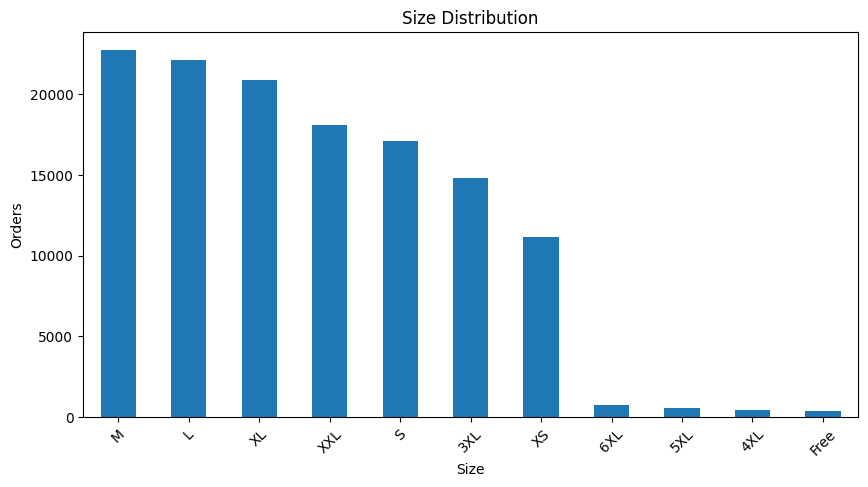

In [46]:
plt.figure(figsize=(10,5))
df_clean['size'].value_counts().plot(kind='bar')
plt.title('Size Distribution')
plt.xlabel('Size')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.show()

SQL

In [49]:
import sqlite3
import pandas as pd

In [50]:
conn = sqlite3.connect("amazon_sales.db")

In [51]:
df_clean.to_sql("amazon_sales", conn, if_exists="replace", index=False)

128975

In [52]:
query = "SELECT * FROM amazon_sales LIMIT 5"

pd.read_sql(query, conn)

,index,order_id,date,status,fulfilment,sales_channel,ship-service-level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship-city,ship-state,ship-postal-code,ship-country,b2b,fulfilled-by,unnamed:_22
0,0,405-8078784-5731545,2022-04-30 00:00:00,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,None,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,0,Easy Ship,None
1,1,171-9198151-1101146,2022-04-30 00:00:00,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,0,Easy Ship,None
2,2,404-0687676-7273146,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,1,None,None
3,3,403-9615377-8133951,2022-04-30 00:00:00,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,None,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,0,Easy Ship,None
4,4,407-1069790-7240320,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,0,None,None


In [55]:
query = """
SELECT COUNT(*) AS Total_Records
FROM amazon_sales;
"""

pd.read_sql(query, conn)

,Total_Records
0,128975


In [57]:
query = """
SELECT ROUND(SUM(amount), 2) AS Total_Sales
FROM amazon_sales;
"""

pd.read_sql(query, conn)


,Total_Sales
0,78592678.3


In [58]:
query = """
SELECT ROUND(AVG(amount), 2) AS Average_Order_Value
FROM amazon_sales;
"""

pd.read_sql(query, conn)


,Average_Order_Value
0,648.56


In [59]:
query = """
SELECT SUM(qty) AS Total_Quantity_Sold
FROM amazon_sales;
"""

pd.read_sql(query, conn)

,Total_Quantity_Sold
0,116649


In [60]:
query = """
SELECT status,
       COUNT(*) AS Total_Orders
FROM amazon_sales
GROUP BY status
ORDER BY Total_Orders DESC;
"""

pd.read_sql(query, conn)

,status,Total_Orders
0,Shipped,77804
1,Shipped - Delivered to Buyer,28769
2,Cancelled,18332
3,Shipped - Returned to Seller,1953
4,Shipped - Picked Up,973
5,Pending,658
6,Pending - Waiting for Pick Up,281
7,Shipped - Returning to Seller,145
8,Shipped - Out for Delivery,35
9,Shipped - Rejected by Buyer,11


In [61]:
query = """
SELECT `ship-state`,
       COUNT(*) AS Total_Orders
FROM amazon_sales
GROUP BY `ship-state`
ORDER BY Total_Orders DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,ship-state,Total_Orders
0,MAHARASHTRA,22260
1,KARNATAKA,17326
2,TAMIL NADU,11483
3,TELANGANA,11330
4,UTTAR PRADESH,10638
5,DELHI,6782
6,KERALA,6585
7,WEST BENGAL,5963
8,ANDHRA PRADESH,5430
9,Gujarat,4489


In [62]:
query = """
SELECT category,
       ROUND(SUM(amount), 2) AS Total_Sales
FROM amazon_sales
GROUP BY category
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, conn)

,category,Total_Sales
0,Set,39204124.03
1,kurta,21299546.70
2,Western Dress,11216072.69
3,Top,5347792.30
4,Ethnic Dress,791217.66
5,Blouse,458408.18
6,Bottom,150667.98
7,Saree,123933.76
8,Dupatta,915.00


In [63]:

query = """
SELECT style,
       ROUND(SUM(amount), 2) AS Total_Sales
FROM amazon_sales
GROUP BY style
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)


,style,Total_Sales
0,JNE3797,2933482.00
1,J0230,1944948.48
2,SET268,1303923.56
3,J0341,1275322.87
4,J0003,981973.75
5,JNE3405,846822.36
6,J0008,819169.96
7,SET345,723402.79
8,SET324,720096.82
9,SET278,719791.48


In [64]:
query = """
SELECT `ship-city`,
       ROUND(SUM(amount), 2) AS Total_Sales
FROM amazon_sales
GROUP BY `ship-city`
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,ship-city,Total_Sales
0,BENGALURU,6849664.99
1,HYDERABAD,4946032.82
2,MUMBAI,3704461.80
3,NEW DELHI,3613874.78
4,CHENNAI,3098745.74
5,PUNE,2338518.18
6,KOLKATA,1414978.87
7,GURUGRAM,1221618.74
8,THANE,1004355.29
9,LUCKNOW,933926.34


In [65]:
query = """
SELECT strftime('%Y-%m', date) AS Month,
       ROUND(SUM(amount), 2) AS Total_Sales
FROM amazon_sales
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,Total_Sales
0,2022-03,101683.85
1,2022-04,28838708.32
2,2022-05,26226476.75
3,2022-06,23425809.38


In [66]:
query = """
SELECT fulfilment,
       COUNT(*) AS Orders,
       ROUND(SUM(amount),2) AS Sales
FROM amazon_sales
GROUP BY fulfilment;
"""

pd.read_sql(query, conn)

,fulfilment,Orders,Sales
0,Amazon,89698,54322151.0
1,Merchant,39277,24270527.3


In [67]:
df_clean.to_csv("amazon_sales_cleaned.csv", index=False)

In [68]:
import os

print(os.getcwd())

/content


In [69]:
from google.colab import files

files.download("amazon_sales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>